In [1]:
# Libraries
import pandas as pd
import numpy as np

# CPU Cores & System
import os
import sys
import psutil

# Jalankan ini hanya jika posisi aktif masih di dalam folder notebooks
if os.getcwd().endswith('notebooks'):
    %cd ..

# Scipy
from scipy.stats import (
    chi2_contingency, 
    ks_2samp, spearmanr
)

# Viz libraries
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline

# Plotting options
%matplotlib inline
mpl.style.use('ggplot')
sns.set(style='whitegrid')

# Import warnings
import warnings
warnings.filterwarnings('ignore')

# Pandas set_option
pd.set_option('display.max_columns', None)

/home/gontommuhammad/credit_risk_modeling


<br>

---
# **Data Preparation:**

In [2]:
from src.utils import importData

# Define data path
data_path = 'data/raw/loan_data_2007_2014.csv'

df = importData(data_path)

df.head()

Origin Data Shape: (466285, 75) - (# Observation, # Column)

...handling duplicate data:
Sum of duplicate data: 0
Shape of duplicated rows: (0, 75)

Before drop rows: (466285, 75)
After drop rows: (466285, 75)


,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,B2,NaN,10+ years,RENT,24000.0,Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I need to upgra...,credit_card,Computer,860xx,AZ,27.65,0.0,Jan-85,1.0,NaN,NaN,3.0,0.0,13648,83.7,9.0,f,0.0,0.0,5861.071414,5831.78,5000.00,861.07,0.00,0.00,0.00,Jan-15,171.62,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,C4,Ryder,< 1 year,RENT,30000.0,Source Verified,Dec-11,Charged Off,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I plan to use t...,car,bike,309xx,GA,1.00,0.0,Apr-99,5.0,NaN,NaN,3.0,0.0,1687,9.4,4.0,f,0.0,0.0,1008.710000,1008.71,456.46,435.17,0.00,117.08,1.11,Apr-13,119.66,NaN,Sep-13,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,C5,NaN,10+ years,RENT,12252.0,Not Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,NaN,small_business,real estate business,606xx,IL,8.72,0.0,Nov-01,2.0,NaN,NaN,2.0,0.0,2956,98.5,10.0,f,0.0,0.0,3003.653644,3003.65,2400.00,603.65,0.00,0.00,0.00,Jun-14,649.91,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,C1,AIR RESOURCES BOARD,10+ years,RENT,49200.0,Source Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/21/11 > to pay for prop...,other,personel,917xx,CA,20.00,0.0,Feb-96,1.0,35.0,NaN,10.0,0.0,5598,21.0,37.0,f,0.0,0.0,12226.302210,12226.30,10000.00,2209.33,16.97,0.00,0.00,Jan-15,357.48,NaN,Jan-15,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,B5,University Medical Group,1 year,RENT,80000.0,Source Verified,Dec-11,Current,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/21/11 > I plan on combi...,other,Personal,972xx,OR,17.94,0.0,Jan-96,0.0,38.0,NaN,15.0,0.0,27783,53.9,38.0,f,766.9,766.9,3242.170000,3242.17,2233.10,1009.07,0.00,0.00,0.00,Jan-16,67.79,Feb-16,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df = df[sorted(df.columns)].set_index('member_id')

# Check if the index is unique
print(f"Is the index unique? {df.index.is_unique}")

df.info()

Is the index unique? True
<class 'pandas.DataFrame'>
Index: 466285 entries, 1296599 to 11061576
Data columns (total 74 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   466285 non-null  int64  
 1   acc_now_delinq               466256 non-null  float64
 2   addr_state                   466285 non-null  str    
 3   all_util                     0 non-null       float64
 4   annual_inc                   466281 non-null  float64
 5   annual_inc_joint             0 non-null       float64
 6   application_type             466285 non-null  str    
 7   collection_recovery_fee      466285 non-null  float64
 8   collections_12_mths_ex_med   466140 non-null  float64
 9   delinq_2yrs                  466256 non-null  float64
 10  desc                         125981 non-null  str    
 11  dti                          466285 non-null  float64
 12  dti_joint                    0 non-null 

<br>

From the EDA results, we need to drop *NaN* on the two datetime columns to produce `credit_history_age_month` → `_years` → `_group`. In production, `issue_d` is replaced with today's date when the user clicks "Apply" `todays_date = pd.Timestamp.now()`

In [4]:
date_columns = ['issue_d', 'earliest_cr_line', 'last_pymnt_d', 'last_credit_pull_d']

df = df.dropna(subset=date_columns)

# IMPORTANT WARNING: Before entering the data preprocessing, 
# make sure the date column has been converted to date and time format 
# because the `binning_v3.py` module or the data binning process requires it.

print(f"Fixed date format and year anomalies...")
# Convert to datetime & fix "future" year simultaneously (Vectorization)
for col in date_columns:
    # Let Pandas guess the %b-%y format (e.g., Jan-14, Dec-68)
    df[col] = pd.to_datetime(df[col], format='%b-%y', errors='coerce')
    
    # Correction if the year jumps into the future (beyond the anchor year 2016)
    # Pandas automatically detects the year '68' as '2068', we change it to '1968'
    future_mask = df[col].dt.year > 2016
    df.loc[future_mask, col] = df.loc[future_mask, col] - pd.DateOffset(years=100)

print(f"Date format successfully corrected!")

Fixed date format and year anomalies...
Date format successfully corrected!


---
### Vintage Analysis:

In [5]:
# Extract quarterly periods (e.g., 2014Q1, 2014Q2, etc.) as vintage representations
vintage_quarter = df['issue_d'].dt.to_period('Q')

# Calculate the percentage distribution of loan_status per quarter (Main Verification Table)
status_dist_pct = pd.crosstab(
    vintage_quarter,
    df['loan_status'],
    normalize='index') * 100

# Calculate the total number of data points (to ensure the sample size is stable)
status_dist_count = pd.crosstab(vintage_quarter, df['loan_status'])

print(f"=== LOAN STATUS DISTRIBUTION BY QUARTERLY VINTAGE (%) ===")
display(status_dist_pct.round(2))

print(f"\n=== NOMINAL TOTAL DATA PER VINTAGE QUARTER ===")
status_dist_count

=== LOAN STATUS DISTRIBUTION BY QUARTERLY VINTAGE (%) ===


loan_status,Charged Off,Current,Default,Does not meet the credit policy. Status:Charged Off,Does not meet the credit policy. Status:Fully Paid,Fully Paid,In Grace Period,Late (16-30 days),Late (31-120 days)
issue_d,,,,,,,,,
2007Q2,0.00,0.00,0.00,0.00,66.67,33.33,0.00,0.00,0.00
2007Q3,5.52,0.00,0.00,16.57,38.67,39.23,0.00,0.00,0.00
2007Q4,9.02,0.00,0.00,20.62,36.08,34.28,0.00,0.00,0.00
2008Q1,9.50,0.00,0.00,13.45,29.08,47.97,0.00,0.00,0.00
2008Q2,8.84,0.00,0.00,13.25,28.11,49.80,0.00,0.00,0.00
2008Q3,9.40,0.00,0.00,8.05,29.53,53.02,0.00,0.00,0.00
2008Q4,13.38,0.00,0.00,3.60,10.29,72.73,0.00,0.00,0.00
2009Q1,10.39,0.00,0.00,3.35,10.06,76.20,0.00,0.00,0.00
2009Q2,11.15,0.00,0.00,2.93,9.14,76.78,0.00,0.00,0.00



=== NOMINAL TOTAL DATA PER VINTAGE QUARTER ===


loan_status,Charged Off,Current,Default,Does not meet the credit policy. Status:Charged Off,Does not meet the credit policy. Status:Fully Paid,Fully Paid,In Grace Period,Late (16-30 days),Late (31-120 days)
issue_d,,,,,,,,,
2007Q2,0,0,0,0,2,1,0,0,0
2007Q3,10,0,0,30,70,71,0,0,0
2007Q4,35,0,0,80,140,133,0,0,0
2008Q1,96,0,0,136,294,485,0,0,0
2008Q2,44,0,0,66,140,248,0,0,0
2008Q3,28,0,0,24,88,158,0,0,0
2008Q4,78,0,0,21,60,424,0,0,0
2009Q1,93,0,0,30,90,682,0,0,0
2009Q2,122,0,0,32,100,840,0,0,0


<br>

---
Addressing three problematic features in the Population Stability Index analysis process:

In [6]:
from src.utils import missing_summary

missing_summary(df[['tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim']])

,Missing Values,Percentage,Total length
tot_coll_amt,70130,15.05,465839
tot_cur_bal,70130,15.05,465839
total_rev_hi_lim,70130,15.05,465839


<br>

**Data Quality Analysis & Temporal Leakage**
>
>
> Based on an initial examination of the raw data, three features were found to have precisely identical missing values: `tot_coll_amt`, `tot_cur_bal`, and `total_rev_hi_lim`, each missing **66,660 rows** of data (**27.54%** of the total population).
> To validate this data loss pattern, a Vintage Analysis (analysis based on the loan issuance year `issue_d`) was performed. The test results revealed the following data loss structure:
> 1. **Old Historical Period (2007–2011):** All three features had a missing rate of 100%. This demonstrates a structural artifact in that LendingClub did not collect or integrate these financial metrics into its reporting system prior to 2012.
> 2. **New Historical Period (2012–2014):** The missing rate dropped to ~0%, indicating that these features are now fully captured in the updated system.
>
>
> Recommended Action:
> Retaining these three features and imputing them using standard imputation methods (such as mean/median imputation) will lead to temporal leakage. The model risks learning spurious correlations where "Empty Data" status indirectly signals older loans (from the 2008 crisis) that have historically had high default rates. > Therefore, to maintain the objectivity of the model when implemented on future data (where the collection data is stable and fully populated), it was decided to **remove (*drop*) these three features completely** from the modeling pipeline.

<br>

In [7]:
issue_year = df['issue_d'].dt.year

vintage_missing_report = (
    df.groupby(issue_year, observed=True)
     .agg(
         total_loans=('issue_d', 'size'),
         missing_tot_coll_amt=('tot_coll_amt', lambda x: x.isna().sum()),
         missing_tot_cur_bal=('tot_cur_bal', lambda x: x.isna().sum()),
         missing_total_rev_hi_lim=('total_rev_hi_lim', lambda x: x.isna().sum())
     )
     .assign(
         missing_rate_tot_coll_amt=lambda d: (d['missing_tot_coll_amt'] / d['total_loans'] * 100).round(2),
         missing_rate_tot_cur_bal=lambda d: (d['missing_tot_cur_bal'] / d['total_loans'] * 100).round(2),
         missing_rate_total_rev_hi_lim=lambda d: (d['missing_total_rev_hi_lim'] / d['total_loans'] * 100).round(2),
     )
)

print(f"=== VINTAGE ANALYSIS: MISSING VALUE BY YEAR ===")
vintage_missing_report

=== VINTAGE ANALYSIS: MISSING VALUE BY YEAR ===


,total_loans,missing_tot_coll_amt,missing_tot_cur_bal,missing_total_rev_hi_lim,missing_rate_tot_coll_amt,missing_rate_tot_cur_bal,missing_rate_total_rev_hi_lim
issue_d,,,,,,,
2007,572,572,572,572,100.00,100.00,100.00
2008,2390,2390,2390,2390,100.00,100.00,100.00
2009,5265,5265,5265,5265,100.00,100.00,100.00
2010,12510,12510,12510,12510,100.00,100.00,100.00
2011,21683,21683,21683,21683,100.00,100.00,100.00
2012,53307,27710,27710,27710,51.98,51.98,51.98
2013,134654,0,0,0,0.00,0.00,0.00
2014,235458,0,0,0,0.00,0.00,0.00


In [8]:
df = df.drop(columns=['tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim'])

<br>

---
We also need to drop `NaN` from the `collections_12_mths_ex_med` & `revol_util` feature. The results from the credit score card and BinningProcess are not good enough to retain.

In [9]:
missing_summary(df[['collections_12_mths_ex_med', 'revol_util']])

,Missing Values,Percentage,Total length
collections_12_mths_ex_med,115,0.02,465839
revol_util,305,0.07,465839


In [10]:
df = df.dropna(subset='collections_12_mths_ex_med')

In [11]:
df = df.dropna(subset='revol_util')

In [12]:
missing_summary(df[['collections_12_mths_ex_med', 'revol_util']])

,Missing Values,Percentage,Total length


In [13]:
# Replace the value 'ANY', 'NONE' to the string 'OTHER'
df['home_ownership'] = df['home_ownership'].replace({
    'ANY': 'OTHER',
    'NONE': 'OTHER'
})
df['home_ownership'].value_counts()

home_ownership
MORTGAGE    235547
RENT        188043
OWN          41607
OTHER          225
Name: count, dtype: int64

In [14]:
# Mapping category to 'other'
df['purpose'] = df['purpose'].replace({
    'vacation': 'other'
})
df['purpose'].value_counts()

purpose
debt_consolidation    273823
credit_card           104056
home_improvement       26461
other                  26028
major_purchase          9792
small_business          6981
car                     5375
medical                 4579
moving                  2982
wedding                 2328
house                   2262
educational              406
renewable_energy         349
Name: count, dtype: int64

<br>

---
### Performance Window:

In [15]:
# Filter mature data first SPECIFICALLY to find objective M values
df_mature = df[df['issue_d'].dt.year.isin([2011, 2012])]

from src.performance_window import (
    compute_time_to_bad_distribution, 
    recommend_performance_window, 
    apply_performance_window_filter,
    eligibility_funnel_report,
    bad_rate_by_vintage,
    safe_horizon_cutoff,
    truncate_to_safe_horizon
)
from typing import List
DEFAULT_BAD_STATUSES: List[str] = [
    'Charged Off', 'Default', 'Late (31-120 days)', 
    'Does not meet the credit policy. Status:Charged Off',
]

# Determine M from granular data.
tt_bad = compute_time_to_bad_distribution(
    df_mature, 
    bad_statuses=DEFAULT_BAD_STATUSES,
    issue_col='issue_d', 
    last_pymnt_col='last_pymnt_d', 
    status_col='loan_status'
)

print(tt_bad.describe())
print(f"---"*18)
print(tt_bad.quantile([0.5, 0.75, 0.9, 0.95]))

M = recommend_performance_window(tt_bad, coverage=0.90)   # starting from the 90th percentile
print("M selected:", M, "month")
print(f"---"*18)

# Apply filter -- `snapshot_date` MUST be the actual extraction date of LendingClub dataset 
# (not issue_d.max() from any split)
snapshot_date = pd.Timestamp("2016-01-01")
result = apply_performance_window_filter(
    df, 
    snapshot_date=snapshot_date, 
    M=M
)
display(eligibility_funnel_report(result))

# Cut the safe horizon
df_safe = truncate_to_safe_horizon(
    result.df, 
    snapshot_date=snapshot_date, 
    M=M
)
# Verification: the bad rate per vintage should now be relatively flat, not rising smoothly as before.
print(f"---"*18)
display(bad_rate_by_vintage(df_safe))

count    11481.00000
mean        18.32201
std         10.43445
min          1.00000
25%         10.00000
50%         17.00000
75%         26.00000
max         58.00000
Name: months_to_bad, dtype: float64
------------------------------------------------------
0.50    17.0
0.75    26.0
0.90    33.0
0.95    36.0
Name: months_to_bad, dtype: float64
M selected: 33 month
------------------------------------------------------


,stage,count,pct_of_input
0,Input population,465422,100.00
1,Excluded: immature (age < M),207779,44.64
2,Excluded: indeterminate status,4361,0.94
3,Eligible (modeling population),253282,54.42


------------------------------------------------------


,vintage,count,bad_rate
0,2007Q3,71,0.211268
1,2007Q4,386,0.297927
2,2008Q1,1007,0.228401
3,2008Q2,495,0.222222
4,2008Q3,295,0.172881
5,2008Q4,582,0.170103
6,2009Q1,890,0.138202
7,2009Q2,1090,0.140367
8,2009Q3,1360,0.125735
9,2009Q4,1910,0.135079


In [16]:
df_safe.loan_status.value_counts()

loan_status
Fully Paid                                             85587
Charged Off                                            16382
Current                                                12672
Does not meet the credit policy. Status:Fully Paid      1914
Does not meet the credit policy. Status:Charged Off      726
Late (31-120 days)                                       499
Default                                                   61
Name: count, dtype: int64

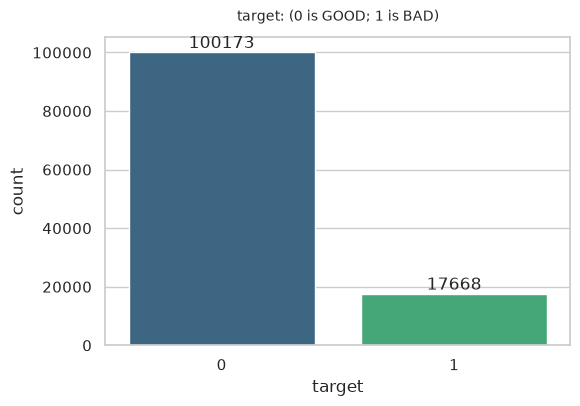

In [17]:
# Target Distribution Visualization
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df_safe, x='target', hue='target', palette='viridis', ax=ax, legend=False)
    
# Add label numbers above each bar
for container in ax.containers: 
    ax.bar_label(container, fmt='%d')
        
ax.set_title('target: (0 is GOOD; 1 is BAD)', fontsize=10, pad=12)
    
# Save figure before show
fig.savefig('Target_Feature_Distribution.png', dpi=150, bbox_inches='tight')

# Show
plt.show()

<br>

---
### **Calculate Information Value**:

In [18]:
from src.utils import calculate_all_iv
tabel_iv = calculate_all_iv(
    df_safe[['annual_inc', 'collections_12_mths_ex_med', 'delinq_2yrs', 'dti', 'inq_last_6mths', 'loan_amnt', 'open_acc', 'revol_bal',
             'pub_rec', 'revol_util', 'total_acc']], 
    target_col=df_safe['target'], num_bins=11)

tabel_iv

,Feature,Information Value (IV)
0,revol_util,0.050348
1,annual_inc,0.041406
2,inq_last_6mths,0.035946
3,dti,0.028330
4,loan_amnt,0.018388
5,total_acc,0.002805
6,revol_bal,0.002690
7,open_acc,0.001381
8,delinq_2yrs,0.000321
9,collections_12_mths_ex_med,0.000000


<br>

---
# 2.0. **Data Preprocessing**:
**The Processing Pipeline**<br>
> 2.1. **Split Input-Output + List of Features to be Used** <br>
> 2.2. **Train-Valid-Test Split** <br>
> 2.3. **Binning Processing & Feature Engineering** <br>

<br>

---
## **2.1. Split Input-Output + List of Features to be Used**:

In [19]:
from src.utils import (
    split_input_output, 
    split_train_test,
    serialize_data,
    deserialize_data,
)

In [20]:
features_to_selected = [
    'annual_inc',
    'collections_12_mths_ex_med',
    'delinq_2yrs',
    'dti',
    'earliest_cr_line',
    'emp_length',
    'home_ownership',
    'inq_last_6mths',
    'issue_d',
    'loan_amnt',
    'open_acc',
    'pub_rec',
    'purpose',
    'revol_bal',
    'revol_util',
    'term',
    'total_acc',
    'verification_status',
    'target'
]
# Perform and call the function
X, y = split_input_output(
    data=df_safe, 
    target_col='target',
    columns_to_keep=features_to_selected
)
# Serialize origin set
serialize_data(X, 'data/interim/X.pkl')
serialize_data(y, 'data/interim/y.pkl')

X shape: (117841, 18)
y shape: (117841,)
Data successfully serialized to data/interim/X.pkl
Data successfully serialized to data/interim/y.pkl


<br>

### **Gini (Decision Tree) - Feature Selection**

In [21]:
import math
from collections import Counter

# Function to calculate entropy
def entropy(labels):
    label_counts = Counter(labels)
    total_elements = len(labels)
    entropy = 0.0
    for label in label_counts:
        prob_of_label = label_counts[label] / total_elements
        entropy -= prob_of_label * math.log2(prob_of_label)
    return round(entropy, 4)

# Function to calculate weighted entropy for a split
def entropy_for_split(data, feature, target):
    unique_values = data[feature].unique()
    total_instances = len(data)
    weighted_entropy = 0.0
    for value in unique_values:
        subset = data[data[feature] == value][target]
        subset_entropy = entropy(subset)
        weighted_entropy += (len(subset) / total_instances) * subset_entropy
    return round(weighted_entropy, 4)

# Function to calculate information gain
def information_gain(data, feature, target):
    overall_entropy = entropy(data[target])
    weighted_entropy = entropy_for_split(data, feature, target)
    info_gain = overall_entropy - weighted_entropy
    return round(info_gain, 4)


# Calculate Information Gain for each feature
features = X.columns.tolist()

# Target variable
target = 'y'

# Call the function and iterate features
info_gain_values = {feature: information_gain(X.assign(y=y), feature, target) for feature in features}

# Sort the features by Information Gain in descending order
sorted_info_gain_values = sorted(info_gain_values.items(), key=lambda item: item[1], reverse=True)

# Print the best feature
best_feature, best_info_gain = sorted_info_gain_values[0]
print(f"Best Feature to choose as Root Node: {best_feature}")
print(f"With Information Gain: {best_info_gain}")

# Print Information Gain for all features
print(f'\nInformation Gain for each feature:')
for feature, gain in sorted_info_gain_values:
    print(f"{feature}: {gain}")

Best Feature to choose as Root Node: revol_bal
With Information Gain: 0.2329

Information Gain for each feature:
revol_bal: 0.2329
annual_inc: 0.0649
dti: 0.0259
emp_length: 0.0238
loan_amnt: 0.0134
revol_util: 0.0119
term: 0.0085
inq_last_6mths: 0.005
earliest_cr_line: 0.0047
purpose: 0.0046
issue_d: 0.0022
verification_status: 0.0018
total_acc: 0.0009
home_ownership: 0.0008
open_acc: 0.0006
pub_rec: 0.0006
delinq_2yrs: 0.0002
collections_12_mths_ex_med: 0.0001


<br>

---
## **2.2. Train-Valid-Test Split**:

In [22]:
# ============================================================================
# STEP 1: SEPARATE FUTURE DATA (OOT TEST SET) BY CLEAN QUARTER CUTOFF
# ============================================================================
# Menggunakan Skema A: 2013Q1 penuh sebagai OOT Test (~3 bulan kalender)
# Catatan: Jika nanti ingin rentang lebih luas (~6 bulan / Skema B), silakan ubah ke '2012-10-01'
oot_cutoff_date = "2013-01-01"
print(f"Cut-off Date untuk OOT Test (Awal Kuartal 2013Q1): {oot_cutoff_date}")

# Buat mask berdasarkan batas tanggal kalender baku
is_oot = X['issue_d'] >= oot_cutoff_date

# Amankan data OOT Test (Data masa depan: 2013Q1 penuh)
X_test = X[is_oot].copy()
y_test = y[is_oot].copy()

# Amankan data Historis untuk basis Train dan Validation (2007 s/d 2012)
X_historical = X[~is_oot].copy()
y_historical = y[~is_oot].copy()

print(f"Step 1 Success:")
print(f" - Shape of Historical Data      : {X_historical.shape[0]} rows (2007 - 2012)")
print(f" - OOT Test Data Shape (Future)  : {X_test.shape[0]} rows (2013Q1)")
print(f"--------------------------------------------------------------------")

# ============================================================================
# STEP 2: SPLIT HISTORICAL DATA INTO TRAIN & VALID (STRATIFIED)
# ============================================================================
# Mempertahankan proporsi Validation sebesar ~10% dari total populasi awal
# Rasio di dalam data historis tetap menggunakan pendekatan 10/90
VAL_SIZE_WITHIN_HISTORICAL = 10 / 90

RANDOM_STATE = 42

print(f"Step 2: Splitting `X_historical` into `X_train` + `X_valid` (Stratified)")
X_train, X_valid, y_train, y_valid = split_train_test(
    X_historical, 
    y_historical,
    test_size=VAL_SIZE_WITHIN_HISTORICAL, 
    stratify=y_historical,
    seed=RANDOM_STATE
)

print(f"-"*22)
print(f"FINAL SPLIT REPORT:")
print(f"X_train shape : {X_train.shape}, y_train : {y_train.shape} | Periode: {X_train['issue_d'].min().date()} s/d {X_train['issue_d'].max().date()}")
print(f"X_valid shape : {X_valid.shape}, y_valid : {y_valid.shape} | Periode: {X_valid['issue_d'].min().date()} s/d {X_valid['issue_d'].max().date()}")
print(f"X_test shape  : {X_test.shape}, y_test  : {y_test.shape} | Periode: {X_test['issue_d'].min().date()} s/d {X_test['issue_d'].max().date()} (OOT)")

Cut-off Date untuk OOT Test (Awal Kuartal 2013Q1): 2013-01-01
Step 1 Success:
 - Shape of Historical Data      : 95360 rows (2007 - 2012)
 - OOT Test Data Shape (Future)  : 22481 rows (2013Q1)
--------------------------------------------------------------------
Step 2: Splitting `X_historical` into `X_train` + `X_valid` (Stratified)
----------------------
FINAL SPLIT REPORT:
X_train shape : (84764, 18), y_train : (84764,) | Periode: 2007-08-01 s/d 2012-12-01
X_valid shape : (10596, 18), y_valid : (10596,) | Periode: 2007-08-01 s/d 2012-12-01
X_test shape  : (22481, 18), y_test  : (22481,) | Periode: 2013-01-01 s/d 2013-03-01 (OOT)


In [23]:
# Validate
print(len(X_train)/len(X))
print(len(X_valid)/len(X))
print(len(X_test)/len(X))

0.7193082203986728
0.08991777055523968
0.19077400904608752


In [24]:
print(f"y_train: {y_train.value_counts()}")
print(f"y_valid: {y_valid.value_counts()}")
print(f"y_test: {y_test.value_counts()}")

y_train: target
0    71846
1    12918
Name: count, dtype: int64
y_valid: target
0    8981
1    1615
Name: count, dtype: int64
y_test: target
0    19346
1     3135
Name: count, dtype: int64


In [25]:
X_train = X_train[sorted(X_train.columns)]
X_valid = X_valid[sorted(X_valid.columns)]
X_test  = X_test[sorted(X_test.columns)]

In [26]:
# Train Fit
serialize_data(X_train, 'data/interim/X_train_raw.pkl')
serialize_data(y_train, 'data/interim/y_train.pkl')

# Validation set
serialize_data(X_valid, 'data/interim/X_valid_raw.pkl')
serialize_data(y_valid, 'data/interim/y_valid.pkl')

# Test set
serialize_data(X_test, 'data/interim/X_test_raw.pkl')
serialize_data(y_test, 'data/interim/y_test.pkl')

Data successfully serialized to data/interim/X_train_raw.pkl
Data successfully serialized to data/interim/y_train.pkl
Data successfully serialized to data/interim/X_valid_raw.pkl
Data successfully serialized to data/interim/y_valid.pkl
Data successfully serialized to data/interim/X_test_raw.pkl
Data successfully serialized to data/interim/y_test.pkl


<br>

---
## **2.3. Binning Processing & Feature Engineering:**

In [27]:
# Import functions and classes from the binning module
from src.binning_woe import (
    fit_binning, 
    transform_binning,
    binning_summary,
    binning_table,
)

# --- MAIN STEPS ---
# 1. FIT ON TRAINING DATA ONLY
# This step calculates edges for quantile columns (annual_inc, etc.) 
# based on the distribution of the training data only. This prevents data leakage.
print(f"Fitting binning using Train data...")
binning_artifacts = fit_binning(X_train.assign(y=y_train), target_col='y')

# 2. Show Summary (Audit Information Value & Status)
summary_df = binning_summary(binning_artifacts)
display(summary_df.sort_values(by='iv', ascending=False))

# IMPORTANT: Check the 'status' column. Everything should be 'OPTIMAL'.
# If it's 'INFEASIBLE', you should loosen the parameters in BINNING_FIT_PARAMS.

(CVXPY) Jul 19 03:40:57 AM: Encountered unexpected exception importing solver HIGHS:
ImportError('/home/gontommuhammad/miniconda3/envs/credit-risk_VENV/lib/python3.13/site-packages/highspy/_core.cpython-313-x86_64-linux-gnu.so: undefined symbol: _ZN5Highs13releaseMemoryEv')


Fitting binning using Train data...

RUNNING SPECIAL/MISSING CONSISTENCY AUDIT


,Bin,Table WoE,Transform WoE,Count,Consistent
Feature,,,,,
annual_inc,Special,0.0,NaN,0,True
annual_inc,Missing,0.0,NaN,0,True


,Bin,Table WoE,Transform WoE,Count,Consistent
Feature,,,,,
credit_age_years,Special,0.0,NaN,0,True
credit_age_years,Missing,0.0,NaN,0,True


,Bin,Table WoE,Transform WoE,Count,Consistent
Feature,,,,,
dti,Special,0.0,NaN,0,True
dti,Missing,0.0,NaN,0,True


...

,Bin,Table WoE,Transform WoE,Count,Consistent
Feature,,,,,
home_ownership,Special,0.0,NaN,0,True
home_ownership,Missing,0.0,NaN,0,True


,Bin,Table WoE,Transform WoE,Count,Consistent
Feature,,,,,
purpose,Special,0.0,NaN,0,True
purpose,Missing,0.0,NaN,0,True


,Bin,Table WoE,Transform WoE,Count,Consistent
Feature,,,,,
term,Special,0.0,NaN,0,True
term,Missing,0.0,NaN,0,True



AUDIT PASSED: All Special & Missing mappings are proven to be consistent.



,name,dtype,status,selected,n_bins,iv,js,gini,quality_score
11,term,categorical,OPTIMAL,True,2,0.101676,0.012592,0.139456,0.185453
5,loan_to_income,numerical,OPTIMAL,True,11,0.095299,0.011805,0.168979,0.014854
7,revol_util,numerical,OPTIMAL,True,11,0.061789,0.007678,0.139202,0.024119
4,inq_last_6mths,numerical,OPTIMAL,True,4,0.048903,0.006086,0.117945,0.161019
10,purpose,categorical,OPTIMAL,True,6,0.040308,0.005017,0.103371,0.078388
0,annual_inc,numerical,OPTIMAL,True,10,0.036383,0.004533,0.105986,0.001556
2,dti,numerical,OPTIMAL,True,11,0.027031,0.003372,0.093529,0.000409
6,open_acc_ratio,numerical,OPTIMAL,True,7,0.009048,0.00113,0.053324,0.006994
8,has_derogatory,categorical,OPTIMAL,True,2,0.006199,0.000774,0.029647,0.009311
3,emp_length_ordinal,numerical,OPTIMAL,True,3,0.005789,0.000721,0.031408,0.009086


In [28]:
# Check the binning details and WoE values for one of the features (example: term)
binning_table(binning_artifacts, 'term')

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,[36_months],66404,0.783399,57811,8593,0.129405,0.190328,0.026542,0.003313
1,[60_months],18360,0.216601,14035,4325,0.235566,-0.538761,0.075133,0.009280
2,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
3,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,84764,1.000000,71846,12918,0.152400,,0.101676,0.012592


In [29]:
binning_table(binning_artifacts, 'loan_to_income')

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.06)",7421,0.087549,6597,824,0.111036,0.364296,0.010213,1.269593e-03
1,"[0.06, 0.10)",9483,0.111875,8392,1091,0.115048,0.324281,0.010490,1.305579e-03
2,"[0.10, 0.13)",8801,0.103829,7721,1080,0.122713,0.25108,0.005991,7.469372e-04
3,"[0.13, 0.16)",8530,0.100632,7466,1064,0.124736,0.232421,0.005009,6.247075e-04
4,"[0.16, 0.19)",8789,0.103688,7631,1158,0.131756,0.169621,0.002811,3.509272e-04
5,"[0.19, 0.23)",11537,0.136107,9842,1695,0.146919,0.043073,0.000249,3.109187e-05
6,"[0.23, 0.26)",6368,0.075126,5403,965,0.151539,0.006678,0.000003,4.178511e-07
7,"[0.26, 0.29)",4563,0.053832,3741,822,0.180145,-0.200535,0.002319,2.893501e-04
8,"[0.29, 0.32)",4866,0.057406,3964,902,0.185368,-0.235509,0.003451,4.303253e-04
9,"[0.32, 0.37)",6225,0.073439,4934,1291,0.207390,-0.37517,0.011729,1.457599e-03


In [30]:
binning_table(binning_artifacts, 'revol_util')

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 16.85)",9726,0.114742,8730,996,0.102406,0.45487,0.020200,0.002503
1,"[16.85, 27.35)",6516,0.076872,5802,714,0.109576,0.379172,0.009663,0.001201
2,"[27.35, 38.55)",8507,0.100361,7428,1079,0.126837,0.213319,0.004237,0.000529
3,"[38.55, 47.55)",8145,0.096090,7007,1138,0.139718,0.101734,0.000960,0.000120
4,"[47.55, 55.05)",7604,0.089708,6470,1134,0.149132,0.025522,0.000058,0.000007
5,"[55.05, 65.95)",12190,0.143811,10261,1929,0.158244,-0.044555,0.000290,0.000036
6,"[65.95, 75.45)",10505,0.123932,8700,1805,0.171823,-0.143141,0.002667,0.000333
7,"[75.45, 80.55)",5594,0.065995,4624,970,0.173400,-0.154184,0.001654,0.000207
8,"[80.55, 85.75)",5447,0.064261,4444,1003,0.184138,-0.227344,0.003590,0.000448
9,"[85.75, 92.65)",6075,0.071670,4897,1178,0.193909,-0.291099,0.006704,0.000835


In [31]:
binning_table(binning_artifacts, 'inq_last_6mths')

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.50)",40651,0.479579,35503,5148,0.126639,0.215106,0.020573,0.002567
1,"[0.50, 1.50)",23255,0.274350,19534,3721,0.160009,-0.057739,0.000933,0.000117
2,"[1.50, 2.50)",12117,0.142950,9964,2153,0.177684,-0.183787,0.005143,0.000642
3,"[2.50, inf)",8741,0.103122,6845,1896,0.216909,-0.432131,0.022254,0.002760
4,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
5,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,84764,1.000000,71846,12918,0.152400,,0.048903,0.006086


In [32]:
binning_table(binning_artifacts, 'purpose')

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"[car, major_purchase]",5489,0.064756,4907,582,0.106030,0.416044,9.671137e-03,1.200248e-03
1,[credit_card],14034,0.165566,12347,1687,0.120208,0.274558,1.132846e-02,1.411627e-03
2,[home_improvement],5377,0.063435,4706,671,0.124791,0.231921,3.144430e-03,3.921753e-04
3,[debt_consolidation],44761,0.528066,37556,7205,0.160966,-0.064845,2.270864e-03,2.838083e-04
4,"[other, small_business]",10170,0.119980,8148,2022,0.198820,-0.322218,1.389292e-02,1.729141e-03
5,"[wedding, medical, moving, house, educational,...",4933,0.058197,4182,751,0.152240,0.001236,8.886555e-08,1.110819e-08
6,Special,0,0.000000,0,0,0.000000,0.0,0.000000e+00,0.000000e+00
7,Missing,0,0.000000,0,0,0.000000,0.0,0.000000e+00,0.000000e+00
Totals,,84764,1.000000,71846,12918,0.152400,,4.030790e-02,5.017011e-03


In [33]:
binning_table(binning_artifacts, 'annual_inc')

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 28572.00)",6316,0.074513,5138,1178,0.186510,-0.243057,0.004783,0.000596
1,"[28572.00, 36836.00)",8415,0.099276,6884,1531,0.181937,-0.212624,0.004827,0.000602
2,"[36836.00, 43986.74)",8348,0.098485,6869,1479,0.177168,-0.180251,0.003404,0.000425
3,"[43986.74, 60606.00)",21866,0.257963,18309,3557,0.162673,-0.077428,0.001588,0.000199
4,"[60606.00, 66096.00)",5441,0.064190,4637,804,0.147767,0.03632,0.000084,0.000010
5,"[66096.00, 75328.50)",8273,0.097600,7094,1179,0.142512,0.078679,0.000588,0.000073
6,"[75328.50, 82718.00)",4555,0.053737,3929,626,0.137431,0.120887,0.000753,0.000094
7,"[82718.00, 92124.00)",5447,0.064261,4718,729,0.133835,0.151563,0.001400,0.000175
8,"[92124.00, 129449.50)",10219,0.120558,9048,1171,0.114590,0.328782,0.011602,0.001444
9,"[129449.50, inf)",5884,0.069416,5220,664,0.112848,0.346067,0.007355,0.000915


In [34]:
binning_table(binning_artifacts, 'dti')

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 5.95)",9867,0.116406,8667,1200,0.121618,0.261298,0.007248,0.000903
1,"[5.95, 7.79)",5066,0.059766,4431,635,0.125345,0.226852,0.002840,0.000354
2,"[7.79, 9.19)",4612,0.054410,3986,626,0.135733,0.13529,0.000950,0.000119
3,"[9.19, 12.23)",11133,0.131341,9603,1530,0.137429,0.120905,0.001840,0.000230
4,"[12.23, 13.82)",6364,0.075079,5439,925,0.145349,0.055654,0.000228,0.000029
5,"[13.82, 16.03)",9086,0.107192,7754,1332,0.146599,0.045624,0.000220,0.000027
6,"[16.03, 17.95)",7647,0.090215,6451,1196,0.156401,-0.030651,0.000086,0.000011
7,"[17.95, 20.16)",8383,0.098898,6991,1392,0.166050,-0.102021,0.001066,0.000133
8,"[20.16, 21.91)",6004,0.070832,4955,1049,0.174717,-0.163343,0.001999,0.000250
9,"[21.91, 27.38)",11920,0.140626,9800,2120,0.177852,-0.184937,0.005124,0.000640


In [35]:
binning_table(binning_artifacts, 'open_acc_ratio')

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.30)",13053,0.153992,11254,1799,0.137823,0.117589,0.002043,0.000255
1,"[0.30, 0.41)",20353,0.240114,17486,2867,0.140864,0.092231,0.001978,0.000247
2,"[0.41, 0.47)",11401,0.134503,9689,1712,0.150162,0.017426,0.000041,0.000005
3,"[0.47, 0.58)",16872,0.199047,14227,2645,0.156769,-0.033433,0.000225,0.000028
4,"[0.58, 0.65)",7515,0.088658,6306,1209,0.160878,-0.064195,0.000374,0.000047
5,"[0.65, 0.78)",9621,0.113503,7992,1629,0.169317,-0.125429,0.001865,0.000233
6,"[0.78, inf)",5949,0.070183,4892,1057,0.177677,-0.183737,0.002523,0.000315
7,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
8,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,84764,1.000000,71846,12918,0.152400,,0.009048,0.001130


In [36]:
binning_table(binning_artifacts, 'has_derogatory')

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,[No_Derogatory],71100,0.838799,60589,10511,0.147834,0.035788,0.001061,0.000133
1,[Has_Derogatory],13664,0.161201,11257,2407,0.176156,-0.173294,0.005138,0.000641
2,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
3,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,84764,1.000000,71846,12918,0.152400,,0.006199,0.000774


In [37]:
binning_table(binning_artifacts, 'emp_length_ordinal')

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 3.50)",30281,0.357239,25879,4402,0.145372,0.05547,0.001078,0.000135
1,"[3.50, 5.50)",13827,0.163123,11785,2042,0.147682,0.036995,0.000220,0.000028
2,"[5.50, inf)",37984,0.448115,32049,5935,0.156250,-0.029504,0.000394,0.000049
3,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
4,Missing,2672,0.031523,2133,539,0.201722,-0.340334,0.004096,0.000510
Totals,,84764,1.000000,71846,12918,0.152400,,0.005789,0.000721


In [38]:
binning_table(binning_artifacts, 'home_ownership')

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,[MORTGAGE],38847,0.458296,33312,5535,0.142482,0.078923,0.002777,0.000347
1,[OWN],6590,0.077745,5549,1041,0.157967,-0.042467,0.000142,0.000018
2,"[RENT, OTHER]",39327,0.463959,32985,6342,0.161263,-0.067045,0.002134,0.000267
3,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
4,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,84764,1.000000,71846,12918,0.152400,,0.005054,0.000632


In [39]:
binning_table(binning_artifacts, 'credit_age_years')

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 7.88)",13867,0.163595,11603,2264,0.163265,-0.081773,0.001125,0.000141
1,"[7.88, 14.79)",38105,0.449542,32130,5975,0.156804,-0.033697,0.000516,0.000065
2,"[14.79, 17.46)",11083,0.130751,9445,1638,0.147794,0.036106,0.000168,0.000021
3,"[17.46, inf)",21709,0.256111,18668,3041,0.140080,0.098721,0.002411,0.000301
4,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
5,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,84764,1.000000,71846,12918,0.152400,,0.004221,0.000528


In [40]:
# 3. TRANSFORM ALL SPLIT DATA
# Apply the previously fitted boundaries to the Train, Valid & Test data for fisrt analysis.
print(f"Transforming all set data first...")
X_train_binned = transform_binning(X_train, binning_artifacts)
X_valid_binned = transform_binning(X_valid, binning_artifacts)
X_test_binned  = transform_binning(X_test, binning_artifacts)

# 4. SAVE THE ARTIFACT FOR PRODUCTION/AUDIT NEEDS
# Save these binning limits so that when predicting new data in the future, we can use the exact same limits.
import joblib

joblib.dump(binning_artifacts, 'binning_artifacts.pkl')
print(f"The binning process is complete and the artifact has been saved!")

Transforming all set data first...
The binning process is complete and the artifact has been saved!


In [41]:
from src.binning_woe import evaluate_bad_rate_monotonicity

report = evaluate_bad_rate_monotonicity(
    X=X_train_binned.assign(y=y_train), 
    bin_col='credit_age_years_woe', 
    target_col='y'
)
report

,credit_age_years_woe,count,bad_count,bad_rate,is_monotonic_increasing,is_monotonic_decreasing
0,-0.081773,13867,2264,0.163265,False,True
1,-0.033697,38105,5975,0.156804,False,True
2,0.036106,11083,1638,0.147794,False,True
3,0.098721,21709,3041,0.140080,False,True


In [42]:
report = evaluate_bad_rate_monotonicity(
    X=X_valid_binned.assign(y=y_valid), 
    bin_col='credit_age_years_woe', 
    target_col='y'
)
report

,credit_age_years_woe,count,bad_count,bad_rate,is_monotonic_increasing,is_monotonic_decreasing
0,-0.081773,1825,305,0.167123,False,True
1,-0.033697,4756,763,0.160429,False,True
2,0.036106,1369,195,0.142440,False,True
3,0.098721,2646,352,0.133031,False,True


In [43]:
report = evaluate_bad_rate_monotonicity(
    X=X_test_binned.assign(y=y_test), 
    bin_col='credit_age_years_woe', 
    target_col='y'
)
report

,credit_age_years_woe,count,bad_count,bad_rate,is_monotonic_increasing,is_monotonic_decreasing
0,-0.081773,2364,355,0.150169,False,False
1,-0.033697,9713,1489,0.153300,False,False
2,0.036106,3229,421,0.130381,False,False
3,0.098721,7175,870,0.121254,False,False


In [44]:
def summarize_features_chi2(X: pd.DataFrame, title: str, features: list, target_col: str) -> pd.DataFrame:
    from scipy.stats import chi2_contingency
    """
    Summarizes the Chi-Square statistical test and monotonicity trend to the feature level (1 row per 1 feature).
    """
    summary_list = []
    
    for feat in features:
        # 1. Buat crosstab untuk uji Chi-Square
        ct = pd.crosstab(X[feat], X[target_col])
        
        # Ensure the contingency table is valid (minimum 2x2)
        if ct.shape[0] > 1 and ct.shape[1] > 1:
            chi2, p_val, dof, _ = chi2_contingency(ct)
        else:
            chi2, p_val, dof = None, None, None
            
        # 2. Calculate aggregate statistics for bad rates
        agg = X.groupby(feat, observed=True)[target_col].agg(['size', 'sum'])
        agg['bad_rate'] = agg['sum'] / agg['size']
        
        # 3. Check the monotonicity of the bad rate from the first to the last bin
        # Use .dropna() on bad_rate to check for empty bins.
        bad_rate_series = agg['bad_rate'].dropna()
        is_inc = bad_rate_series.is_monotonic_increasing
        is_dec = bad_rate_series.is_monotonic_decreasing
        
        # Naming trends for easy reading
        if is_inc:
            trend = 'Increasing'
        elif is_dec:
            trend = 'Decreasing'
        else:
            trend = 'Not Monotonic'
        
        # 4. Enter into dictionary per feature
        summary_list.append({
            'feature': feat,
            'num_of_bins': ct.shape[0],
            'chi_square': chi2,
            'p-value': p_val,
            'DoF': dof,
            'min_bad_rate': agg['bad_rate'].min(),
            'max_bad_rate': agg['bad_rate'].max(),
            'is_monotonic_inc': is_inc,
            'is_monotonic_dec': is_dec,
            'trend': trend
        })
    
    # Convert list to DataFrame
    summary_list_df = pd.DataFrame(summary_list)
    
    # --- Summary Documentation ---
    num_features = summary_list_df.shape[0]
    num_significant = summary_list_df[summary_list_df['p-value'] < 0.05].shape[0]
    num_not_monotonic = summary_list_df[summary_list_df['trend'] == 'Not Monotonic'].shape[0]

    print(f"# {title}:")
    print(f"Number of Features: {num_features}")
    print(f"Number of Features with `p-value` below 0.05: {num_significant}")
    print(f"Number of Features with `Not Monotonic` trend: {num_not_monotonic}")
    
    return summary_list_df


# --- RUN ---
list_of_cat_features = X_train_binned.select_dtypes(
    # make sure all object types 
    # or str types are converted to category first
    include=['category']).columns.tolist()

# Call the summary function
chi2_summary = summarize_features_chi2(
    X=X_train_binned.assign(y=y_train), 
    title='Training Set',
    features=X_train_binned.columns, 
    target_col='y'
)

# You can sort by smallest `p-value` / largest `chi_square` 
# to see which features are most statistically influential
chi2_summary.sort_values(by='p-value', ascending=False)

# Training Set:
Number of Features: 12
Number of Features with `p-value` below 0.05: 12
Number of Features with `Not Monotonic` trend: 0


,feature,num_of_bins,chi_square,p-value,DoF,min_bad_rate,max_bad_rate,is_monotonic_inc,is_monotonic_dec,trend
1,credit_age_years_woe,4,45.721885,6.498692e-10,3,0.140080,0.163265,False,True,Decreasing
9,home_ownership_woe,3,55.079561,1.095533e-12,2,0.142482,0.161263,False,True,Decreasing
3,emp_length_ordinal_woe,4,68.640285,8.344022e-15,3,0.145372,0.201722,False,True,Decreasing
8,has_derogatory_woe,2,70.954302,3.655957e-17,1,0.147834,0.176156,False,True,Decreasing
6,open_acc_ratio_woe,7,100.299214,2.173317e-19,6,0.137823,0.177677,False,True,Decreasing
2,dti_woe,11,296.889749,7.063838e-58,10,0.121618,0.195002,False,True,Decreasing
0,annual_inc_woe,10,385.184511,1.980436e-77,9,0.112848,0.186510,False,True,Decreasing
10,purpose_woe,6,430.765766,6.912005e-91,5,0.106030,0.198820,False,True,Decreasing
4,inq_last_6mths_woe,4,560.829317,3.123122e-121,3,0.126639,0.216909,False,True,Decreasing
7,revol_util_woe,11,660.253686,2.125807e-135,10,0.102406,0.218182,False,True,Decreasing


In [45]:
# Call the summary function
chi2_summary = summarize_features_chi2(
    X=X_valid_binned.assign(y=y_valid),
    title='Validation Set',
    features=X_train_binned.columns, 
    target_col='y'
)
chi2_summary.sort_values(by='p-value', ascending=False)

# Validation Set:
Number of Features: 12
Number of Features with `p-value` below 0.05: 11
Number of Features with `Not Monotonic` trend: 7


,feature,num_of_bins,chi_square,p-value,DoF,min_bad_rate,max_bad_rate,is_monotonic_inc,is_monotonic_dec,trend
3,emp_length_ordinal_woe,4,5.377600,1.461456e-01,3,0.143025,0.190751,False,False,Not Monotonic
6,open_acc_ratio_woe,7,14.825442,2.165871e-02,6,0.136969,0.179647,False,False,Not Monotonic
1,credit_age_years_woe,4,14.170996,2.681401e-03,3,0.133031,0.167123,False,True,Decreasing
9,home_ownership_woe,3,12.566840,1.867005e-03,2,0.139329,0.165076,False,True,Decreasing
2,dti_woe,11,39.747640,1.876907e-05,10,0.110379,0.191201,False,False,Not Monotonic
8,has_derogatory_woe,2,19.239354,1.153116e-05,1,0.145724,0.188060,False,True,Decreasing
10,purpose_woe,6,54.460369,1.685456e-10,5,0.108621,0.187162,False,False,Not Monotonic
7,revol_util_woe,11,76.529421,2.395474e-12,10,0.096591,0.202096,False,False,Not Monotonic
0,annual_inc_woe,10,74.636623,1.864093e-12,9,0.095170,0.192211,False,False,Not Monotonic
4,inq_last_6mths_woe,4,94.772784,2.066071e-20,3,0.124876,0.236347,False,True,Decreasing


In [46]:
# Call the summary function
chi2_summary = summarize_features_chi2(
    X=X_test_binned.assign(y=y_test),
    title='Test Set',
    features=X_train_binned.columns, 
    target_col='y'
)
chi2_summary.sort_values(by='p-value', ascending=False)

# Test Set:
Number of Features: 12
Number of Features with `p-value` below 0.05: 11
Number of Features with `Not Monotonic` trend: 8


,feature,num_of_bins,chi_square,p-value,DoF,min_bad_rate,max_bad_rate,is_monotonic_inc,is_monotonic_dec,trend
8,has_derogatory_woe,2,0.251056,6.163324e-01,1,0.138816,0.141765,False,True,Decreasing
3,emp_length_ordinal_woe,4,19.119178,2.583161e-04,3,0.132743,0.189873,False,False,Not Monotonic
1,credit_age_years_woe,4,39.796907,1.176534e-08,3,0.121254,0.153300,False,False,Not Monotonic
6,open_acc_ratio_woe,7,52.995359,1.175818e-09,6,0.117239,0.168919,False,False,Not Monotonic
9,home_ownership_woe,3,65.040649,7.526662e-15,2,0.122366,0.161123,False,True,Decreasing
7,revol_util_woe,11,93.054325,1.325108e-15,10,0.076923,0.196144,False,False,Not Monotonic
4,inq_last_6mths_woe,4,91.591673,9.969084e-20,3,0.119910,0.177694,False,False,Not Monotonic
10,purpose_woe,6,116.641994,1.613375e-23,5,0.093548,0.233806,False,False,Not Monotonic
11,term_woe,2,117.188804,2.610005e-27,1,0.126614,0.188396,False,True,Decreasing
2,dti_woe,11,170.484863,2.201460e-31,10,0.084992,0.197641,False,False,Not Monotonic


In [47]:
from src.population_stability_index import psi_report
print(psi_report(X_train_binned, X_valid_binned, bin_columns=X_train_binned.columns))

                   feature  psi_total verdict
0       open_acc_ratio_woe   0.001195  Stable
1       loan_to_income_woe   0.001138  Stable
2                  dti_woe   0.000881  Stable
3           annual_inc_woe   0.000633  Stable
4     credit_age_years_woe   0.000626  Stable
5           revol_util_woe   0.000609  Stable
6                 term_woe   0.000239  Stable
7              purpose_woe   0.000161  Stable
8       inq_last_6mths_woe   0.000088  Stable
9       has_derogatory_woe   0.000073  Stable
10  emp_length_ordinal_woe   0.000069  Stable
11      home_ownership_woe   0.000018  Stable


In [48]:
print(psi_report(X_train_binned, X_test_binned, bin_columns=X_train_binned.columns))

                   feature  psi_total                        verdict
0              purpose_woe   0.196490  Moderate shift -- investigate
1           revol_util_woe   0.129503  Moderate shift -- investigate
2                  dti_woe   0.113545  Moderate shift -- investigate
3       loan_to_income_woe   0.094496                         Stable
4           annual_inc_woe   0.052334                         Stable
5     credit_age_years_woe   0.041607                         Stable
6   emp_length_ordinal_woe   0.036983                         Stable
7       home_ownership_woe   0.024457                         Stable
8       has_derogatory_woe   0.019227                         Stable
9       open_acc_ratio_woe   0.016819                         Stable
10      inq_last_6mths_woe   0.007723                         Stable
11                term_woe   0.000466                         Stable


In [49]:
X_train_binned.info()

<class 'pandas.DataFrame'>
Index: 84764 entries, 1006175 to 1367503
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   annual_inc_woe          84764 non-null  float64
 1   credit_age_years_woe    84764 non-null  float64
 2   dti_woe                 84764 non-null  float64
 3   emp_length_ordinal_woe  84764 non-null  float64
 4   inq_last_6mths_woe      84764 non-null  float64
 5   loan_to_income_woe      84764 non-null  float64
 6   open_acc_ratio_woe      84764 non-null  float64
 7   revol_util_woe          84764 non-null  float64
 8   has_derogatory_woe      84764 non-null  float64
 9   home_ownership_woe      84764 non-null  float64
 10  purpose_woe             84764 non-null  float64
 11  term_woe                84764 non-null  float64
dtypes: float64(12)
memory usage: 10.4 MB


<br>

---
## **Feature check**:

In [50]:
from src.utils import compute_vif
compute_vif(X_train_binned, target_col=None)

               feature    VIF
                 const 1.0407
        annual_inc_woe 1.4029
  credit_age_years_woe 1.2551
               dti_woe 1.1590
emp_length_ordinal_woe 1.0609
    inq_last_6mths_woe 1.0219
    loan_to_income_woe 1.3023
    open_acc_ratio_woe 1.1561
        revol_util_woe 1.1026
    has_derogatory_woe 1.0219
    home_ownership_woe 1.1872
           purpose_woe 1.0096
              term_woe 1.1638


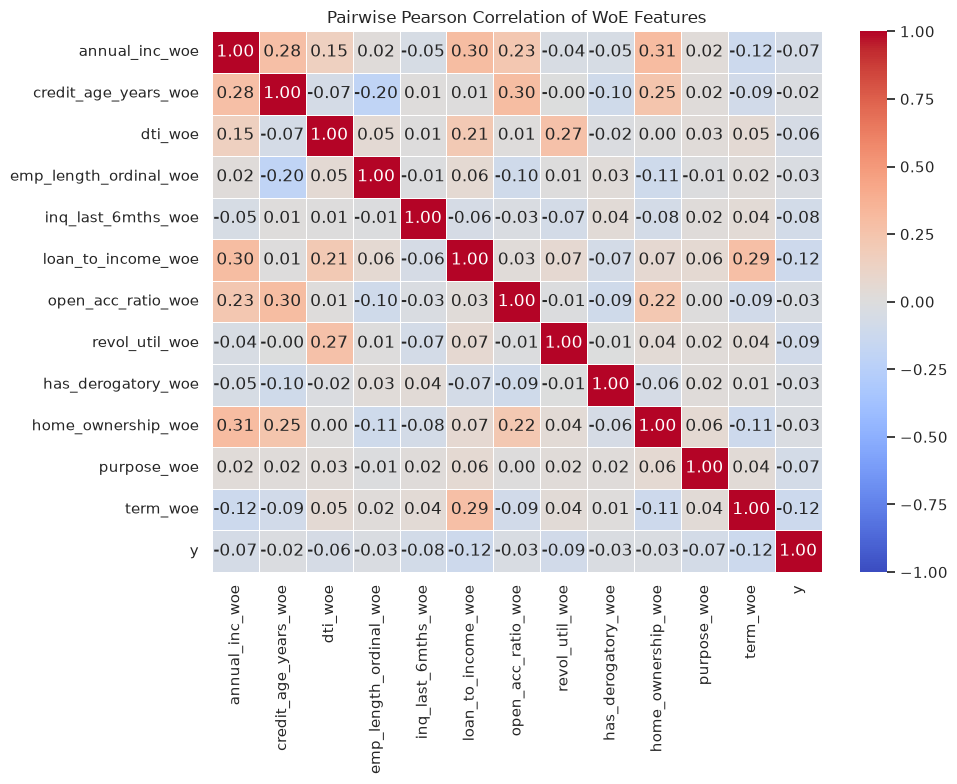

There are no feature pairs with correlation >= 0.5


In [51]:
# 1. Calculate Pairwise Pearson Correlation
corr_matrix = X_train_binned.assign(y=y_train).corr(method='pearson')

# 2. Plot Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    vmin=-1, 
    vmax=1,
    linewidths=0.5
)
plt.title(f"Pairwise Pearson Correlation of WoE Features")
plt.tight_layout()
plt.show()

# 3. Look for Feature Pairs with High Correlation (Suspected Multicollinearity)
# The correlation threshold is usually 0.5 or 0.6 for credit risk models.
threshold = 0.5  

# Take the upper triangle of the correlation matrix so that there are no duplications (A-B and B-A)
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = []
for col in upper_tri.columns:
    for row in upper_tri.index:
        val = upper_tri.loc[row, col]
        if abs(val) >= threshold:
            high_corr_pairs.append({
                'Feature 1': row,
                'Feature 2': col,
                'Correlation': val
            })

high_corr_df = pd.DataFrame(high_corr_pairs)
if not high_corr_df.empty:
    high_corr_df = high_corr_df.sort_values(by='Correlation', key=abs, ascending=False).reset_index(drop=True)
    print(f"=== FEATURE PAIRS WITH HIGH CORRELATION (SUSPECTS) ===")
    print(high_corr_df)
else:
    print(f"There are no feature pairs with correlation >= {threshold}")

In [52]:
from sklearn.feature_selection import mutual_info_classif
# Mutual information measures the dependency between a feature and its target.
mi_scores = mutual_info_classif(
    X_train_binned, 
    y_train,
    discrete_features='auto'
)
mi_scores = pd.Series(
    mi_scores, 
    index=X_train_binned.columns
)

# Sort Feature Score
mi_scores = mi_scores.sort_values(
    ascending=False
)

pd.set_option('display.max_rows', None)
mi_scores

# selected_features = mi_scores[mi_scores > 0.01].index

# X_selected = X[selected_features]

term_woe                  0.013628
loan_to_income_woe        0.008242
home_ownership_woe        0.006727
credit_age_years_woe      0.006437
inq_last_6mths_woe        0.005776
annual_inc_woe            0.005630
purpose_woe               0.005492
has_derogatory_woe        0.004355
dti_woe                   0.004277
revol_util_woe            0.004203
emp_length_ordinal_woe    0.004049
open_acc_ratio_woe        0.002500
dtype: float64

<br>

---
* **Serialize Data set for Logistic Regression**:

In [53]:
X_train_binned = X_train_binned[sorted(X_train_binned.columns)]
X_valid_binned = X_valid_binned[sorted(X_valid_binned.columns)]
X_test_binned  = X_test_binned[sorted(X_test_binned.columns)]

# LogReg Set
serialize_data(X_train_binned, 'data/processed/logreg/X_train_lr.pkl')
serialize_data(X_valid_binned, 'data/processed/logreg/X_valid_lr.pkl')
serialize_data(X_test_binned, 'data/processed/logreg/X_test_lr.pkl')

Data successfully serialized to data/processed/logreg/X_train_lr.pkl
Data successfully serialized to data/processed/logreg/X_valid_lr.pkl
Data successfully serialized to data/processed/logreg/X_test_lr.pkl
